# ECE 447: Anomaly Detection — Part 2
## Credit Card Fraud Detection

**Team:** Yaaqoob Choulli · Liam Reschke · Tairan Xi

This notebook implements three unsupervised anomaly detection methods:
1. **Statistical** — Mahalanobis Distance
2. **Distance-Based** — k-Nearest Neighbors (kNN, k=5)
3. **Machine Learning** — Isolation Forest

Covers threshold optimization, evaluation (Precision/Recall/F1, ROC, PR, confusion matrix),
interpretability, and MLflow experiment tracking.

## 0. Setup

In [9]:
# Uncomment to install dependencies
# !pip install mlflow scikit-learn pandas numpy matplotlib seaborn

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import IsolationForest
from sklearn.manifold import TSNE
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay
)

import mlflow
import mlflow.sklearn
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')
print('Imports OK.')

Imports OK.


## 1. Data Loading & Exploration

The Kaggle credit card fraud dataset contains **284,807 transactions** (~492 fraudulent, 0.173% fraud rate).
Features V1–V28 are PCA-transformed (anonymized), plus `Time` and `Amount`.

In [11]:
df = pd.read_csv('creditcard.csv')
print(f'Shape: {df.shape}\n')
print('Class distribution:')
print(df['Class'].value_counts())
print(f'\nFraud rate: {df["Class"].mean()*100:.3f}%')
df.head()

Shape: (284807, 31)

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud rate: 0.173%


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


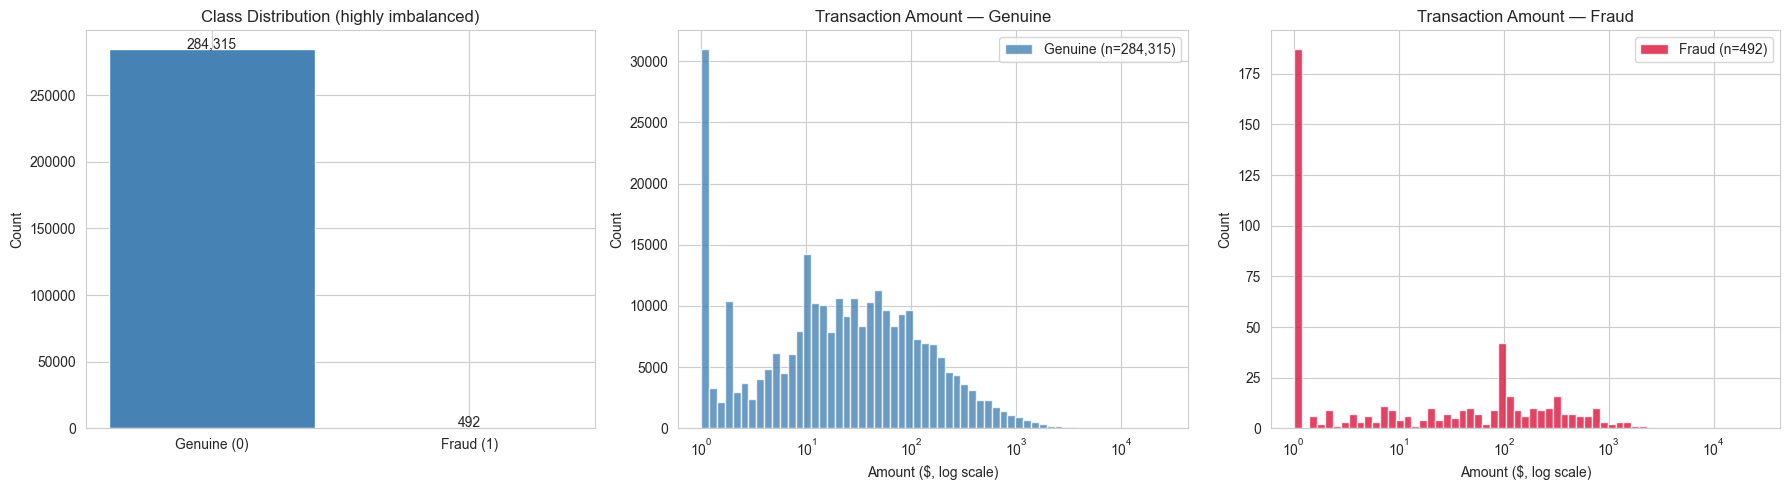

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Class imbalance
counts = df['Class'].value_counts() # Mapping of 0 to Genuine and 1 to fraudulent
axes[0].bar(['Genuine (0)', 'Fraud (1)'], counts.values, color=['steelblue', 'crimson'])
axes[0].set_title('Class Distribution (highly imbalanced)')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center')

# Graph out the transaction amount distribution for both classes on a log scale to better visualize the long tail of amounts. We clip the minimum to $1
bins = np.logspace(0, np.log10(df['Amount'].max() + 1), 60)  # start at $1
axes[1].hist(df[df['Class']==0]['Amount'].clip(lower=1), bins=bins, alpha=0.8,
             color='steelblue', label=f'Genuine (n={counts[0]:,})')
axes[1].set_xscale('log')
axes[1].set_title('Transaction Amount — Genuine')
axes[1].set_xlabel('Amount ($, log scale)')
axes[1].set_ylabel('Count')
axes[1].legend()

axes[2].hist(df[df['Class']==1]['Amount'].clip(lower=1), bins=bins, alpha=0.8,
             color='crimson', label=f'Fraud (n={counts[1]:,})')
axes[2].set_xscale('log')
axes[2].set_title('Transaction Amount — Fraud')
axes[2].set_xlabel('Amount ($, log scale)')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()


The plots above illustrate a few important things. The class distribution charts highlights how imbalanced these two classes are. We have a total of 492 fraudulent charges which is meager compared to the over 250 000 genuine charges. Whats more interesting is the transaction amount plots. The middle plot visualizes genuine transaction amounts and shows a large concentration of small charges (between 1-10$), and then begins to follow a relatively normal distrubution where the majority if charges fall in the 10-100$ range, tapering off as we enter the 1000$+ range. The fraudulent chage visualtion follows the same inital pattern of a large concentration of small charges, but then resembes a more uniform distrubution from the 10-1000$ range. There is one tall bucket in the middle of this logarithmic range (approx. 100$), but other than that and the first bucket, its quite uniformly shaped.

## 2. Preprocessing

Due to the private nature of transations, most features in our data have been scaled and anonymized (titles are not descriptive, it is ambuguous what most features exactly represent). We do have the origninal, raw values for amount and time, however. Features V1-V28 are already seemingly scaled, but it is not obvious what range they have been scaled to. For all features in this dataset, it is prudent that we apply normalization to all features to eliminate nay ambiguity and potenitial domination in differently scaled features.
- Stratified 80/20 train/test split preserves the 0.173% fraud rate

Training is unsupervised, that is, there is no ground truth during training. The model will look for outliers in the dataset which it may flag as divergent from the majority class, but it received no confirmation of the correctness of its choices, only we as engineers do when evaulating it versus a ground truth. 

In [13]:
scaler = StandardScaler()

# Standardize all features — V1-V28 are PCA-centered but not unit-variance,
# and Amount/Time are raw. Scaling everything ensures kNN distances are fair.
FEATURE_COLS = [f'V{i}' for i in range(1, 29)] + ['Amount', 'Time']
X_raw = df[FEATURE_COLS].values
y     = df['Class'].values

X = scaler.fit_transform(X_raw)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Features: {len(FEATURE_COLS)} (all standardized to mean=0, std=1)')
print(f'Train: {X_train.shape[0]:,} samples  | Fraud: {y_train.sum()} ({y_train.mean()*100:.3f}%)')
print(f'Test:  {X_test.shape[0]:,} samples  | Fraud: {y_test.sum()} ({y_test.mean()*100:.3f}%)')

Features: 30 (all standardized to mean=0, std=1)
Train: 227,845 samples  | Fraud: 394 (0.173%)
Test:  56,962 samples  | Fraud: 98 (0.172%)


## 3. Method 1 — Statistical: Mahalanobis Distance

Mahalanobis distance measures how far a point is from the distribution mean,
scaled by and accounting for feature covariance:

$$d_M(x) = \sqrt{(x - \mu)^T \Sigma^{-1} (x - \mu)}$$

**Why it fits:** V1–V28 come from PCA, so a multivariate normal assumption is reasonable.
High distance → the transaction deviates strongly from the typical pattern → flagged as anomaly.

No labels are used — we compute μ and Σ⁻¹ from training features only.

In [14]:
mean_train = np.mean(X_train, axis=0)
cov_train  = np.cov(X_train, rowvar=False)
cov_inv    = np.linalg.pinv(cov_train)  # pseudoinverse for numerical stability

def mahalanobis_scores(X, mean, cov_inv):
    """Vectorized Mahalanobis distance for every row in X."""
    diff = X - mean
    return np.sqrt(np.einsum('ij,jk,ik->i', diff, cov_inv, diff))

scores_mahal_train = mahalanobis_scores(X_train, mean_train, cov_inv)
scores_mahal_test  = mahalanobis_scores(X_test,  mean_train, cov_inv)

print('Mahalanobis score stats (test set):')
print(f'  Genuine — mean={scores_mahal_test[y_test==0].mean():.2f}, std={scores_mahal_test[y_test==0].std():.2f}')
print(f'  Fraud   — mean={scores_mahal_test[y_test==1].mean():.2f}, std={scores_mahal_test[y_test==1].std():.2f}')

Mahalanobis score stats (test set):
  Genuine — mean=4.74, std=2.56
  Fraud   — mean=22.56, std=14.14


## 4. Method 2 — Distance-Based: k-Nearest Neighbors (kNN)

Each transaction is scored by its **mean distance to its k=5 nearest neighbors**.
Anomalies are isolated from the dense cluster of genuine transactions and therefore
have larger mean distances.

> **Note on efficiency:** kNN is fit on a 20% stratified sample of the training set
> (~45k points) to keep runtime reasonable on this 284k-row dataset.
> `ball_tree` is used for efficient approximate search in 30 dimensions.

In [15]:
K           = 5
SAMPLE_FRAC = 0.2

# Stratified sample for kNN training
sample_idx   = np.random.choice(len(X_train), size=int(len(X_train) * SAMPLE_FRAC), replace=False)
X_train_knn  = X_train[sample_idx]

knn = NearestNeighbors(n_neighbors=K, algorithm='ball_tree', n_jobs=-1)
knn.fit(X_train_knn)
print(f'kNN fitted on {len(X_train_knn):,} samples (k={K})')

# Anomaly score = mean distance to K nearest neighbors
dist_train, _ = knn.kneighbors(X_train)
scores_knn_train = dist_train.mean(axis=1)

dist_test, _  = knn.kneighbors(X_test)
scores_knn_test  = dist_test.mean(axis=1)

print(f'kNN score stats (test set):')
print(f'  Genuine — mean={scores_knn_test[y_test==0].mean():.3f}, std={scores_knn_test[y_test==0].std():.3f}')
print(f'  Fraud   — mean={scores_knn_test[y_test==1].mean():.3f}, std={scores_knn_test[y_test==1].std():.3f}')

kNN fitted on 45,569 samples (k=5)
kNN score stats (test set):
  Genuine — mean=1.867, std=1.487
  Fraud   — mean=9.007, std=6.240


## 5. Method 3 — Machine Learning: Isolation Forest

Isolation Forest builds an ensemble of random trees. Anomalous points are
**isolated in fewer splits** (shorter average path length), yielding a higher anomaly score.

- `contamination` is set to the known fraud rate (~0.173%) to guide internal threshold calibration
- `decision_function` is negated so that **higher score = more anomalous**
- 100 estimators for stable, low-variance scores

In [16]:
contamination = float(y_train.mean())
print(f'Contamination: {contamination:.5f}')

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=contamination,
    random_state=42,
    n_jobs=-1
)
iso_forest.fit(X_train)
print('Isolation Forest fitted.')

# Negate: higher score = more anomalous
scores_if_train = iso_forest.decision_function(X_train)
scores_if_test  = iso_forest.decision_function(X_test)

print(f'IF score stats (test set):')
print(f'  Genuine — mean={scores_if_test[y_test==0].mean():.4f}, std={scores_if_test[y_test==0].std():.4f}')
print(f'  Fraud   — mean={scores_if_test[y_test==1].mean():.4f}, std={scores_if_test[y_test==1].std():.4f}')

Contamination: 0.00173
Isolation Forest fitted.
IF score stats (test set):
  Genuine — mean=0.2440, std=0.0421
  Fraud   — mean=0.0536, std=0.0908


# Part 3 - Threshold Optimization

## Notes:
1. Analyze anomaly score distributions: \
   Visually compare the scores of genuine transactions versus fraudulent ones.
3. Select and justify detection threshold: \
   Pick a specific numerical cutoff for each model and defend it using simulated business or engineering constraints.
5. Perform sensitivity analysis: \
    Show how slightly tweaking that threshold impacts the model's performance.


## 3.1 Visualizing the Distributions

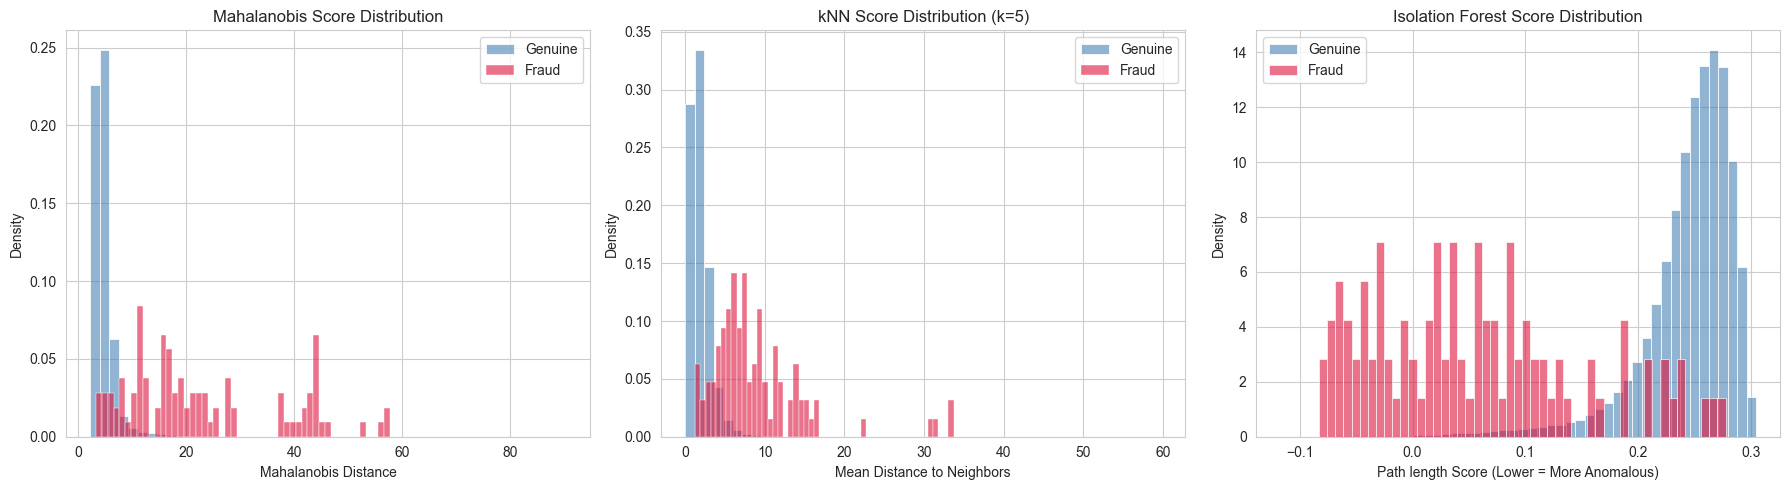

In [17]:
# 6. Threshold Optimization - Score Distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Mahalanobis Distance
sns.histplot(scores_mahal_test[y_test==0], bins=50, color='steelblue', stat='density', alpha=0.6, label='Genuine', ax=axes[0])
sns.histplot(scores_mahal_test[y_test==1], bins=50, color='crimson', stat='density', alpha=0.6, label='Fraud', ax=axes[0])
axes[0].set_title('Mahalanobis Score Distribution')
axes[0].set_xlabel('Mahalanobis Distance')
axes[0].legend()

# Plot 2: k-Nearest Neighbors
sns.histplot(scores_knn_test[y_test==0], bins=50, color='steelblue', stat='density', alpha=0.6, label='Genuine', ax=axes[1])
sns.histplot(scores_knn_test[y_test==1], bins=50, color='crimson', stat='density', alpha=0.6, label='Fraud', ax=axes[1])
axes[1].set_title('kNN Score Distribution (k=5)')
axes[1].set_xlabel('Mean Distance to Neighbors')
axes[1].legend()

# Plot 3: Isolation Forest
sns.histplot(scores_if_test[y_test==0], bins=50, color='steelblue', stat='density', alpha=0.6, label='Genuine', ax=axes[2])
sns.histplot(scores_if_test[y_test==1], bins=50, color='crimson', stat='density', alpha=0.6, label='Fraud', ax=axes[2])
axes[2].set_title('Isolation Forest Score Distribution')
axes[2].set_xlabel('Path length Score (Lower = More Anomalous)')
axes[2].legend()

plt.tight_layout()
plt.show()

#### General Observation:
Across all three plots we can see that the genuine transactions (blue) are very condensed on the left side. They form sharp spikes at the lower end of the x-axis. On the other hand the fraudulent transactions (red) generally have higher distances/scores and trail off to the right of the x-axis.

#### Mahalanobis Distribution:
Looking at the Mahalanobis plot we see that genuine transactions lie in the range of a distance of zero to about 10 where it forms a very sharp spike. \
We can see that there is quite a bit of overlap of fraud values across the entire base of the 'genuine' spike. One reason that could be attributed to this is the fact that fraudulent transactions try to mock or mimic normal behavior to avoid being detected, with this being said it makes sense that their transactions sit close to the statistical mean of the data. 

#### k-Nearest Neighbors (kNN) Distribution:

Similar to the prior plot, the kNN plot shows genuine transactions clumping tightly with very low mean distances to their neighbors (mostly between 0 and 5). \
The fraudulent transactions have a much wider, flatter spread stretching out to the right. However compared to the MD, the spread is less. On the topic of overlap/separation between the classes, we see very similar results to the prior plot. We can see we have some overlap however the peak(s) of the fraudulent curve is mostly separated. We can attribute these results/observations to the fact that kNN looks at local neighbors rather than a global mean. As a result it is better at finding fraud that occurs in sparse 'regions' of data, but struggles with embedded fraud transactions.

#### Isolation Forest Distribution:

The final plot, Isolation Forest, shows the clearest distinction between the two classes. The genuine transactions form a steep curve spreading spike at the higher average path length scores, we can see it appears to be normal distributed with a slight left skew. When it comes the fraud distribution. we see a less clear pattern but a denser population of values in the lower range of average path length

This is exactly the output we would expect to see. The real transactions have a longer path length on average, explained by the predicatable and reasonable series of feature values typically associated with a real transaction. These more "normal" data points are more difficult to isolate due to their similarity among other authentic transactions. On the other hand, the fraudulent points have a much shorter average path, because their anomalous features serve as effective data to isolate these transactions from authenic ones, therefore requiring less decisions in the decision tree to isolate these fraudulent data points. 

## 3.2 Threshold Selection and Justification

#### Selected Thresholds:
Given the three graphs above we need to select a hard cutoff for the best differentiation between the classes, fraudulent or genuine. 
With that being said we have selected the following initial detection thresholds:
1. Mahalanobis Distance Threshold: >12 = Fraudulent
2. k-Nearest Neighbors (kNN) Threshold: >4.5 = Fraudulent
3. Isolation Forest Threshold - <0.2 = Fraudulent

## 3.3 Sensitivity Analysis

For each method we sweep across many candidate thresholds and record Precision, Recall, and F1 at each one.
This shows whether our chosen threshold sits at a reasonable operating point, and how sensitive performance is to small shifts in the threshold.

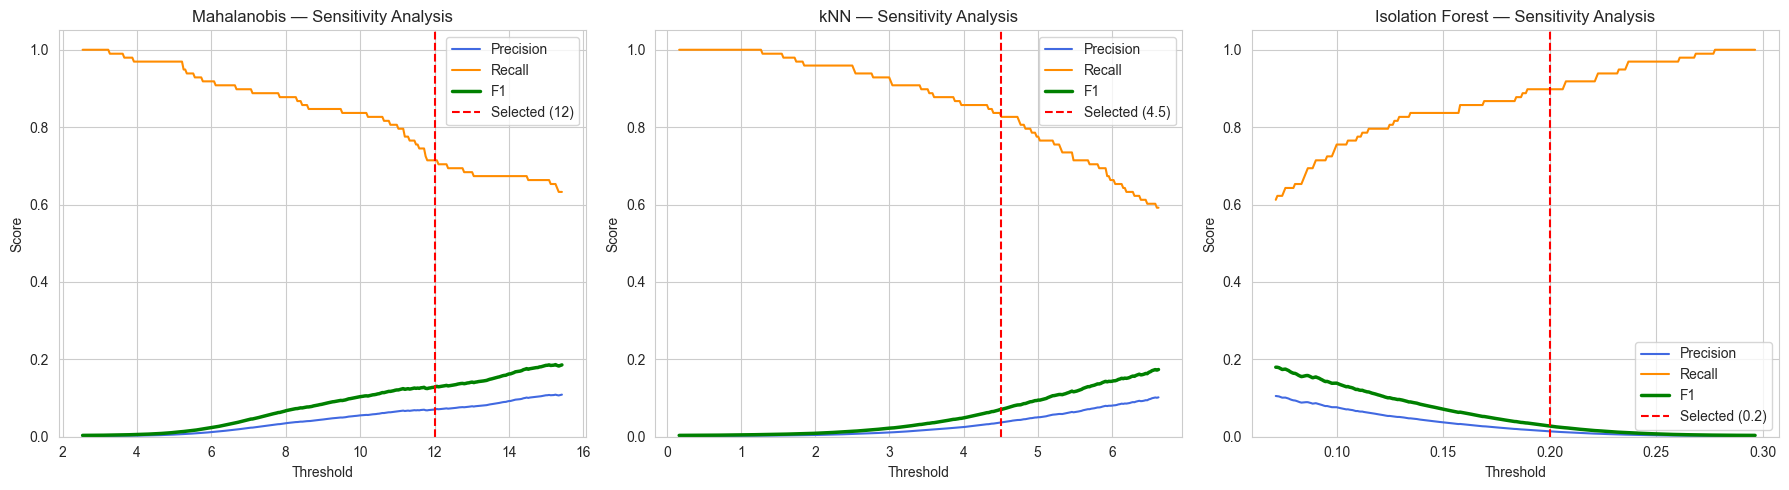

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Mahalanobis — flag if score >= threshold
thresholds_mahal = np.linspace(np.percentile(scores_mahal_test, 1), np.percentile(scores_mahal_test, 99), 300)
p_mahal, r_mahal, f_mahal = [], [], []
for t in thresholds_mahal:
    preds = (scores_mahal_test >= t).astype(int)
    p_mahal.append(precision_score(y_test, preds, zero_division=0))
    r_mahal.append(recall_score(y_test, preds, zero_division=0))
    f_mahal.append(f1_score(y_test, preds, zero_division=0))

axes[0].plot(thresholds_mahal, p_mahal, label='Precision', color='royalblue')
axes[0].plot(thresholds_mahal, r_mahal, label='Recall',    color='darkorange')
axes[0].plot(thresholds_mahal, f_mahal, label='F1',        color='green', linewidth=2.5)
axes[0].axvline(12, color='red', linestyle='--', linewidth=1.5, label='Selected (12)')
axes[0].set_title('Mahalanobis — Sensitivity Analysis')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.05)
axes[0].legend()

# kNN — flag if score >= threshold
thresholds_knn = np.linspace(np.percentile(scores_knn_test, 1), np.percentile(scores_knn_test, 99), 300)
p_knn, r_knn, f_knn = [], [], []
for t in thresholds_knn:
    preds = (scores_knn_test >= t).astype(int)
    p_knn.append(precision_score(y_test, preds, zero_division=0))
    r_knn.append(recall_score(y_test, preds, zero_division=0))
    f_knn.append(f1_score(y_test, preds, zero_division=0))

axes[1].plot(thresholds_knn, p_knn, label='Precision', color='royalblue')
axes[1].plot(thresholds_knn, r_knn, label='Recall',    color='darkorange')
axes[1].plot(thresholds_knn, f_knn, label='F1',        color='green', linewidth=2.5)
axes[1].axvline(4.5, color='red', linestyle='--', linewidth=1.5, label='Selected (4.5)')
axes[1].set_title('kNN — Sensitivity Analysis')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')
axes[1].set_ylim(0, 1.05)
axes[1].legend()

# Isolation Forest — flag if score <= threshold (lower = more anomalous, no negation)
thresholds_if = np.linspace(np.percentile(scores_if_test, 1), np.percentile(scores_if_test, 99), 300)
p_if, r_if, f_if = [], [], []
for t in thresholds_if:
    preds = (scores_if_test <= t).astype(int)
    p_if.append(precision_score(y_test, preds, zero_division=0))
    r_if.append(recall_score(y_test, preds, zero_division=0))
    f_if.append(f1_score(y_test, preds, zero_division=0))

axes[2].plot(thresholds_if, p_if, label='Precision', color='royalblue')
axes[2].plot(thresholds_if, r_if, label='Recall',    color='darkorange')
axes[2].plot(thresholds_if, f_if, label='F1',        color='green', linewidth=2.5)
axes[2].axvline(0.2, color='red', linestyle='--', linewidth=1.5, label='Selected (0.2)')
axes[2].set_title('Isolation Forest — Sensitivity Analysis')
axes[2].set_xlabel('Threshold')
axes[2].set_ylabel('Score')
axes[2].set_ylim(0, 1.05)
axes[2].legend()

plt.tight_layout()
plt.savefig('sensitivity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## Sensitivity Analysis Observations
The low Precision and F1 scores across all three methods are expected given the extreme class imbalance in this dataset (0.173% fraud). Even a small false positive rate generates hundreds of incorrecrlty flagged genuine transactions, far outnumbering the true positives and suppressing precision naturally.

Mahalanobis (threshold = 12): The selected threshold sits near the F1 peak, representing a reasonable balance between precision and recall. Recall is high at this point which means we are catching most fraud cases, and while precision is low, this is consistent with what we expect from an imbalanced dataset, therefore this threshold is good.

kNN (threshold = 4.5): Similar to Mahalanobis, the selected threshold falls close to the F1 peak. The curves behave as expected — recall starts high and drops as the threshold increases, while precision rises slowly. This threshold is kept.

Isolation Forest (threshold = 0.2): The selected threshold of 0.2 is too high. Looking at the plot, F1 peaks much earlier (around 0.08–0.10) and has already collapsed to near zero by the time we reach 0.2. This means at our current threshold, the model is flagging almost nothing as fraud. We will adjust this threshold downward to align with the F1 peak.